# Data Exploration

In [26]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.pipeline.data_processor import DataProcessor

sns.set_style('whitegrid')
%matplotlib inline

## Load Data

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
processor = DataProcessor()

jobs, x_train, y_train, x_test = processor.load_data()

print(f"Jobs: {len(jobs)}")
print(f"Train sessions: {len(x_train)}")
print(f"Test sessions: {len(x_test)}")

Jobs: 21917
Train sessions: 15882
Test sessions: 1819


In [29]:
x_train.head()

,session_id,job_ids,actions
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view..."
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']"
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a..."
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ..."
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ..."


In [30]:
y_train.head()

,session_id,job_id,action
0,0,84,view
1,1,241,view
2,2,303,apply
3,3,171,apply
4,4,286,apply


## Prepare Sequences

In [31]:
x_train = processor.prepare_sequences(x_train)
x_test = processor.prepare_sequences(x_test)

## Session Length Analysis

In [32]:
x_train['seq_length'].describe()

count    15882.000000
mean         7.539793
std          3.577731
min          3.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         15.000000
Name: seq_length, dtype: float64

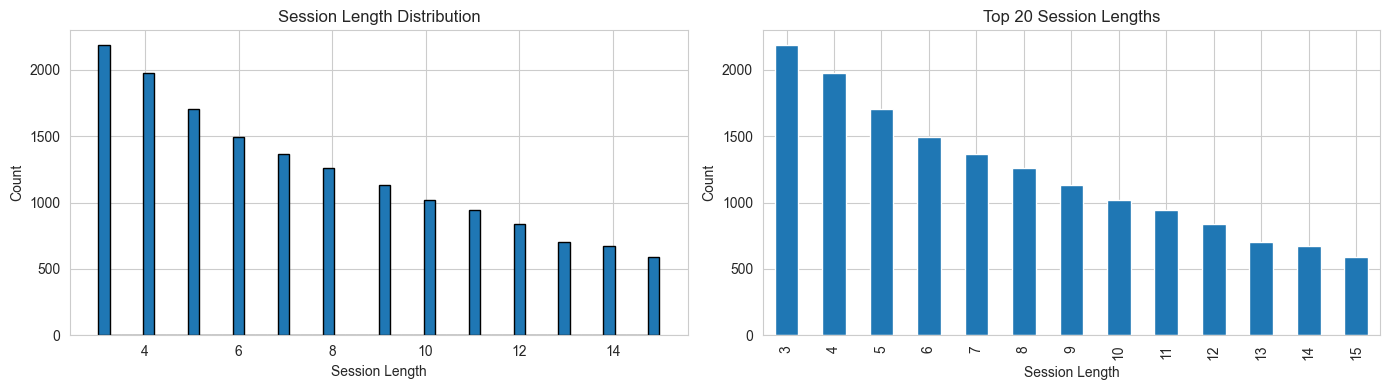

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(x_train['seq_length'], bins=50, edgecolor='black')
axes[0].set_xlabel('Session Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Session Length Distribution')

x_train['seq_length'].value_counts().head(20).sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Session Length')
axes[1].set_ylabel('Count')
axes[1].set_title('Top 20 Session Lengths')

plt.tight_layout()
plt.show()

## Job Popularity

In [34]:
all_jobs = []
for jobs_list in x_train['jobs_list']:
    all_jobs.extend(jobs_list)

job_counts = Counter(all_jobs)

print(f"Unique jobs: {len(job_counts)}")
print(f"Total views: {len(all_jobs)}")
print(f"\nTop 10 most viewed:")
for job_id, count in job_counts.most_common(10):
    print(f"  Job {job_id}: {count} views")

Unique jobs: 20505
Total views: 119747

Top 10 most viewed:
  Job 518: 176 views
  Job 50: 164 views
  Job 302: 163 views
  Job 41: 159 views
  Job 2975: 152 views
  Job 1460: 152 views
  Job 88: 144 views
  Job 85: 143 views
  Job 3736: 142 views
  Job 1620: 142 views


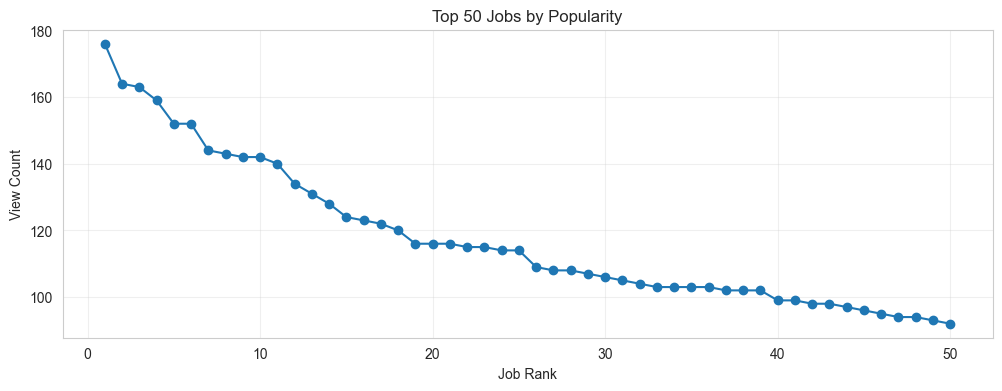

In [35]:
top_jobs = pd.Series([count for _, count in job_counts.most_common(50)])

plt.figure(figsize=(12, 4))
plt.plot(range(1, 51), top_jobs.values, marker='o')
plt.xlabel('Job Rank')
plt.ylabel('View Count')
plt.title('Top 50 Jobs by Popularity')
plt.grid(True, alpha=0.3)
plt.show()

## Action Distribution

In [36]:
all_actions = []
for actions_list in x_train['actions_list']:
    all_actions.extend(actions_list)

action_counts = Counter(all_actions)
print("Actions in sequences:")
for action, count in action_counts.items():
    print(f"  {action}: {count} ({count/len(all_actions)*100:.1f}%)")

Actions in sequences:
  view: 76115 (63.6%)
  apply: 43632 (36.4%)


In [37]:
print("\nTarget actions (next action):")
print(y_train['action'].value_counts())
print("\nPercentages:")
print(y_train['action'].value_counts(normalize=True) * 100)


Target actions (next action):
action
view     9608
apply    6274
Name: count, dtype: int64

Percentages:
action
view     60.496159
apply    39.503841
Name: proportion, dtype: float64


## Target Jobs Analysis

In [38]:
target_job_counts = Counter(y_train['job_id'])

print(f"Unique target jobs: {len(target_job_counts)}")
print(f"\nTop 10 target jobs:")
for job_id, count in target_job_counts.most_common(10):
    print(f"  Job {job_id}: {count} times")

Unique target jobs: 7030

Top 10 target jobs:
  Job 518: 28 times
  Job 41: 28 times
  Job 1620: 26 times
  Job 1460: 24 times
  Job 155: 24 times
  Job 89: 23 times
  Job 50: 23 times
  Job 332: 22 times
  Job 85: 22 times
  Job 66: 21 times
